# GoalLab Stage 06: Improve the controller with PPO

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 05](05_policy_gradient.ipynb) · [Stage 07](07_preference_and_grpo.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/apply-theory/06_ppo.ipynb)

**Build:** a PPO evidence controller with fixed rollout probabilities, GAE, and clipped policy updates.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 06](../../../notebooks/06_ppo.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Calculate clipped objectives for both advantage signs; inspect GAE recursion; preserve old rollout probabilities.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: clipping is asymmetric through the advantage sign

With positive advantage, PPO stops rewarding a large probability increase. With negative advantage, it stops rewarding an excessive decrease. Compute both signs rather than memorizing one diagram.

The denominator is the probability under the rollout policy. It stays fixed for all optimization epochs on that batch. The clipped objective is not a hard bound on every action probability or on KL.

In [2]:
ratios=np.array([.6,1.,1.4])
table(['Ratio','Advantage +2','Advantage -2'],[[r,min(r*2,np.clip(r,.8,1.2)*2),min(r*(-2),np.clip(r,.8,1.2)*(-2))] for r in ratios])
delta=np.array([.2,-.1,.8]); gae=np.zeros(3); carry=0.
for t in reversed(range(3)):
    carry=delta[t]+.95*carry; gae[t]=carry
print('GAE for the example TD residuals:',gae)
assert np.isclose(gae[-1],.8)

| Ratio | Advantage +2 | Advantage -2 |
|---|---|---|
| 0.6 | 1.2 | -1.6 |
| 1.0 | 2.0 | -2.0 |
| 1.4 | 2.4 | -2.8 |

GAE for the example TD residuals: [0.827 0.66  0.8  ]


## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
from collections import deque
from copy import deepcopy
from torch import nn
from torch.distributions import Categorical
EvidenceMDP = goal.EvidenceMDP
greedy = learning.greedy
network = learning.network
def network(outputs):
    return nn.Sequential(nn.Linear(7, 32), nn.Tanh(), nn.Linear(32, outputs))


def train_policy(method='PPO', seed=7, episodes=600):
    if method not in {'REINFORCE', 'Actor-Critic', 'PPO'} or episodes % 24:
        raise ValueError('Supported policy method and a multiple of 24 episodes required')
    torch.manual_seed(seed)
    env, rng = EvidenceMDP(), np.random.default_rng(seed)
    features = torch.tensor(env.features())
    actor, critic = network(2), network(1)
    params = list(actor.parameters()) + ([] if method == 'REINFORCE' else list(critic.parameters()))
    optimizer = torch.optim.Adam(params, lr=.01 if method != 'PPO' else .004)
    history = []
    for update in range(episodes // 24):
        batch = []
        for _ in range(24):
            s = env.start_index
            for _ in range(4):
                with torch.no_grad():
                    dist = Categorical(logits=actor(features[s]))
                    a = dist.sample()
                    logp, value = dist.log_prob(a), critic(features[s]).squeeze()
                ns, r, done = env.step(s, int(a), rng)
                batch.append((s, int(a), r, float(logp), float(value)))
                s = ns
        states = torch.tensor([b[0] for b in batch])
        actions = torch.tensor([b[1] for b in batch])
        rewards = torch.tensor([b[2] for b in batch]).reshape(24, 4)
        old_logp = torch.tensor([b[3] for b in batch])
        values = torch.tensor([b[4] for b in batch]).reshape(24, 4)
        next_values = torch.cat([values[:, 1:], torch.zeros(24, 1)], dim=1)
        delta = rewards + next_values - values
        returns = torch.flip(torch.cumsum(torch.flip(rewards, [1]), 1), [1])
        if method == 'REINFORCE':
            advantage, targets = returns.flatten(), returns.flatten()
        elif method == 'Actor-Critic':
            advantage, targets = delta.flatten(), (rewards + next_values).flatten()
        else:
            gae, carry = torch.zeros_like(values), torch.zeros(24)
            for t in reversed(range(4)):
                carry = delta[:, t] + .95 * carry
                gae[:, t] = carry
            targets, advantage = (gae + values).flatten(), gae.flatten()
            advantage = (advantage - advantage.mean()) / (advantage.std(unbiased=False) + 1e-8)
        for _ in range(4 if method == 'PPO' else 1):
            dist = Categorical(logits=actor(features[states]))
            logp = dist.log_prob(actions)
            if method == 'PPO':
                ratio = (logp - old_logp).exp()
                actor_loss = -torch.minimum(ratio * advantage, ratio.clamp(.8, 1.2) * advantage).mean()
            else:
                actor_loss = -(logp * advantage).mean()
            loss = actor_loss - .01 * dist.entropy().mean()
            if method != 'REINFORCE':
                loss += .5 * nn.functional.mse_loss(critic(features[states]).squeeze(1), targets)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(params, 1); optimizer.step()
        with torch.no_grad():
            policy = actor(features).softmax(-1).numpy()
        history.append(((update + 1) * 24 * 4, env.values(policy)[0][env.start_index]))
    return {'env': env, 'policy': policy, 'model': actor, 'history': np.array(history)}

## 1. Why freeze rollout probabilities?

PPO compares the current action probability to the probability when the action was collected. Updating the denominator would erase the reference. Here each rollout contains 24 full episodes; four optimization epochs reuse it. GAE uses gamma=1 and lambda=0.95, with zero terminal continuation.

The minimum of unclipped and clipped advantage terms limits incentives for large helpful probability changes. It is not an enforced trust-region guarantee.

Positive-advantage surrogate: [1.2 2.  2.4]


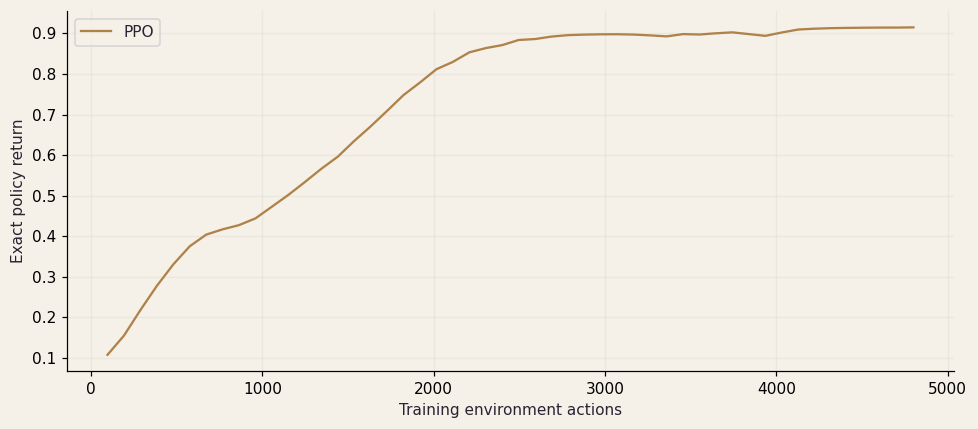

| Controller | Exact return | Held-out briefing success | Calls/case |
|---|---|---|---|
| PPO | 0.915 | 99.0% | 4.0 |

In [4]:
ratios = np.array([.6,1.,1.4]); advantage = 2.
print('Positive-advantage surrogate:',np.minimum(ratios*advantage,np.clip(ratios,.8,1.2)*advantage))
run = train_policy('PPO',7,1200)
learning_plot({'PPO':run}); report_policies({'PPO':run})

## 2. From policy output to evidence artifact

The operational boundary remains the same: select a structured action, validate it, then evaluate the submitted briefing independently.

In [5]:
session = run['env'].deploy(run['policy'],workspace)
print(session.artifact,goal.verify(workspace,session.artifact))

Briefing(value=11, citation='test-7-source-1', period='2026-02', abstained=False) {'success': True, 'supported': True, 'value_correct': True}


## Interpret the evidence

The stochastic actor may occasionally fail even when its greedy version succeeds. Both are legitimate deployment choices, but their evaluation distributions differ. Report the choice and retain the probability trace.

## Change a constraint: predict first

Turn the stochastic policy into a greedy policy for evaluation. Predict the difference and explain why it is a changed deployment policy.

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
deterministic = learning.greedy(run['policy'])
print('Stochastic success:',learning.heldout(run['policy'])['success'])
print('Greedy success:',learning.heldout(deterministic)['success'])
print('Report which deployment policy was evaluated; do not silently mix them.')

Stochastic success: 0.99
Greedy success: 1.0
Report which deployment policy was evaluated; do not silently mix them.


## What this stage contributes

A PPO controller with an explicit training-versus-deployment distinction. Theory: [GAE](../../../chapters/29-generalized-advantage-estimation/README.md), [PPO](../../../chapters/31-proximal-policy-optimization/README.md).

[Stage 05](05_policy_gradient.ipynb) · [Stage 07](07_preference_and_grpo.ipynb)